# Transfer Learning in Reinforcement Learning: DQN vs PPO on Othello

## 1. Introduction

### The Game

Othello (Reversi) is a two-player strategy game on an N×N grid. Players take turns
placing discs. Each placement must flank one or more of the opponent's discs in a
straight line; the flanked discs flip to the placing player's colour. The game ends
when neither player can move; the player with more discs wins.

Despite simple rules, Othello has real strategic depth. Corner squares can never be
flipped — a disc there is permanent — making corner control the central objective.
Edge squares adjacent to corners are only stable once the corner is taken, so early
grabs can backfire. Mid-game play often sacrifices immediate piece count for positional
advantage. This means a "flip as many pieces as possible now" heuristic (our Greedy
baseline) actively loses against positional play, which is what makes learned agents
interesting.

### Why Reinforcement Learning?

There is no database of expert Othello games to learn from. The only feedback
available is the game result: win, lose, or draw. RL fits naturally here: the agent picks moves, plays the game out, and uses the outcome to figure out
which decisions were good. Over many games it gradually discovers what works.

### This Project

We compare two RL algorithms across two training conditions:

- **Direct training**: learn 8×8 Othello from scratch.
- **Transfer learning**: pre-train on 6×6, then fine-tune on 8×8.

The algorithms are DQN (off-policy, replay buffer) and PPO (on-policy, no memory).
The 6×6 and 8×8 boards share the same rules and strategic logic, so a network trained
on 6×6 should have learned spatial features — flanking patterns, edge threats, corner
adjacency — that transfer directly to the larger board.

The central question: **does 6×6 pre-training help on 8×8, and does the answer differ
between DQN and PPO?** The algorithms differ in one key way that matters for transfer:
DQN's replay buffer stores and revisits early fine-tuning transitions; PPO discards
every rollout after one update. This difference drives the main hypothesis.

## Related Work

**DQN.** Mnih et al. (2015) showed that a CNN with experience replay and a target network could achieve human-level performance on Atari games from raw pixels. The two-network design (online network for action selection, lagged target network for TD targets) is the core stability mechanism used here.

**PPO.** Schulman et al. (2017) introduced a clipped surrogate objective that makes policy gradient updates more stable than vanilla REINFORCE without the complexity of TRPO. PPO has become the standard on-policy baseline in RL due to its simplicity and strong empirical performance across a wide range of tasks.

**Transfer learning in RL.** Taylor and Stone (2009) survey transfer in RL broadly. The most direct form, initialising a new network with weights from a trained one, works best when source and target share structural similarity. Our setup is strong on this point: same rules, same CNN backbone, only the board size changes. The adaptive pooling layer makes this weight-compatible by construction.

**TD-Gammon.** Tesauro (1994) showed that a neural network trained by temporal difference learning and self-play could reach expert level at backgammon. This was the first strong evidence that self-play RL alone could produce expert-level game play without human data, and directly motivated later work including AlphaGo.

**Self-play.** Silver et al. (2016, 2017) demonstrated that self-play alone can produce superhuman game-playing agents. We use a lightweight version: the agent trains against a periodically-updated frozen copy of itself, avoiding the need for human data or a fixed opponent library.

In [2]:
# pull latest code if repo already cloned, otherwise clone fresh
import os
if os.path.exists("othello-rl"):
    !git -C rl-othello pull
else:
    !git clone https://github.com/guerlain-hitier/rl-othello.git
%cd rl-othello
!pip install -r requirements.txt -q


Cloning into 'othello-rl'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 121 (delta 69), reused 92 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 74.70 KiB | 1.96 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/kaggle/working/othello-rl/othello-rl


In [3]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib

# default plot size and resolution for all figures in this notebook
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from othello.env import OthelloEnv
from othello.networks import DqnNetwork, PpoNetwork
from othello.baselines import random_agent, greedy_agent
from othello.dqn import DqnAgent
from othello.ppo import PpoAgent
from othello.train import train_dqn, train_ppo, evaluate_vs_random
from othello.transfer import transfer_dqn, transfer_ppo
from othello.evaluate import round_robin, compute_elo, print_standings

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

# fix all sources of randomness so results are reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to {SEED}")

# warm up numba JIT on a tiny board so the first real game does not pause to compile
try:
    from othello import env_kernels as _k
    import numpy as _np
    _tmp = _np.zeros((4, 4), dtype=_np.int8)
    _k.get_legal_mask(_tmp, 1, 4)
    _k.has_any_legal_move(_tmp, 1, 4)
    _k.place_and_flip(_tmp, 0, 1, 1, 4)
    del _tmp, _k
    print("numba JIT compiled and ready")
except ImportError:
    print("numba not found - falling back to pure Python game loop (slower)")


Using device: cuda
PyTorch version: 2.10.0+cu128
numba JIT compiled and ready


In [4]:
# checkpoint directory -- works on Kaggle and Colab without any mounting
import os
if os.path.isdir("/kaggle/working"):
    CHECKPOINT_DIR = "/kaggle/working/othello-rl-checkpoints"
else:
    CHECKPOINT_DIR = "/content/othello-rl-checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")


Checkpoints will be saved to: /kaggle/working/othello-rl-checkpoints


## 2. Hyperparameters

All four training runs share the same hyperparameters for fair comparison.
These were chosen to be reasonable defaults for a free Colab T4 GPU,
not extensively tuned per-algorithm (which would confound the transfer comparison).

Key choices and rationale:

**DQN `epsilon_decay = 3,000,000` steps**

30k episodes across 256 parallel games gives roughly 7.7M total environment steps
($30{,}000 \times 256 \approx 7.7\text{M}$). Setting decay to 3M means $\varepsilon$
hits its floor at step 3M, which is about 40% of the way through training
($3\text{M} / 7.7\text{M} \approx 0.39$). The remaining 60% of training runs fully
exploitative. Decay much shorter (say 1M) collapses exploration too early; much longer
(say 7M) keeps the agent exploring into the final episodes where it should be refining.

**PPO `rollout_len = 2048`**

Each PPO update collects 2048 transitions across 256 parallel games before updating,
so each game contributes about $2048 / 256 = 8$ steps per update on average. A typical
8x8 Othello game lasts ~60 moves (the board has 64 squares with 4 occupied at the
start, leaving at most 60 placements), so an update fires roughly every 8 steps into
each game. This is short enough that the data stays fresh (on-policy constraint), and long
enough to compute stable advantage estimates with GAE.

**`parallel_games = 256`**

A T4 GPU has 16GB VRAM. The network forward pass is small (roughly 2MB per batch).
At 256 games the GPU occupancy is high and the overhead per game is negligible.
Doubling to 512 gave no measurable speedup in testing, so 256 was kept as the
practical ceiling for this hardware.

**`opponent_update_freq = 3000`**

$30{,}000 / 3{,}000 = 10$ opponent refreshes across the full training run, one every
10%. This keeps the self-play target challenging as the agent improves, without
updating so often that the agent is always chasing a moving target.

**Train/eval separation**: every evaluation call uses `explore=False` (greedy for DQN,
argmax for PPO) against a fixed baseline. Evaluation games are never stored in the
replay buffer or rollout buffer. No feedback from the eval signal into the training
gradient.

**Reward shaping**: the step reward is `0` for non-terminal moves. At game end the
agent receives $(my\_score - opp\_score) / total\_pieces$, normalised to $(-1, +1)$.
This score-margin signal gives a stronger gradient than binary win/loss: an agent that
wins 40-24 gets a larger reward than one that wins 33-31, encouraging dominant play
rather than just any win.


In [5]:
# all 4 runs use the same values so the comparison is fair
pretrain_episodes = 20_000
finetune_episodes = 30_000
direct_episodes   = 30_000

# DQN settings
dqn_lr             = 1e-4
gamma              = 0.99
epsilon_start      = 1.0
epsilon_end        = 0.05
epsilon_decay      = 3_000_000   # steps to decay from 1.0 to 0.05
batch_size         = 256
buffer_cap         = 200_000
target_update_freq = 1000        # sync target net every N gradient steps

# PPO settings
ppo_lr          = 3e-4
lam             = 0.95           # GAE lambda, controls bias/variance tradeoff
clip_epsilon    = 0.2            # max allowed policy ratio change per update
entropy_coeff   = 0.01           # small bonus to discourage premature convergence
value_coeff     = 0.5
ppo_epochs      = 4              # passes over the same rollout before discarding
mini_batch_size = 256
rollout_len     = 2048           # transitions collected before each PPO update

parallel_games       = 256       # games run simultaneously on GPU per step
eval_freq            = 2000
eval_games           = 50
opponent_update_freq = 3000      # how often the frozen self-play opponent is refreshed
checkpoint_freq      = 5000

print("hyperparameters set")


hyperparameters set


### A note on training speed

Training 50k self-play games means the game loop runs millions of times. The first
baseline implementation ran at about 25 minutes for 30k episodes on a T4, too slow
to iterate on. Five changes brought it down to under 6 minutes:

**Numba JIT** (`env_kernels.py`): the inner board loops (checking legal moves,
flipping pieces) are compiled to native machine code using
[Numba](https://numba.readthedocs.io). The first call takes around 3s to compile
(cached to disk after that), then runs at roughly C speed. This is the biggest
single win, around 10-50x on the game loop alone.

**Pre-allocated GPU buffers** (`_state_buf`, `_mask_buf`): the original code called
`torch.from_numpy()` on every move, allocating new GPU memory each time. These
buffers are now allocated once at agent init and filled in-place with `.copy_()`
per step, eliminating per-step allocation overhead.

**state_dict copy instead of deepcopy** (`frozen_net`): the frozen self-play opponent
was cloned with `copy.deepcopy()`, which copies the entire Python object graph.
Replaced with a fresh network instance and `load_state_dict()`, which only transfers
the weight tensors, around 100x faster for a sync that happens every few thousand
episodes.

**Batched parallel games**: `parallel_games=256` games run in lockstep. All agent
moves across active games are batched into one GPU forward pass per step, dropping
GPU round trips from 50 x N down to 50 regardless of N.

**Reduced eval frequency**: cut from 100 games every 1000 episodes to 50 games
every 2000 episodes, same signal, a fraction of the wall-clock cost.


## 3. Environment

The environment supports any even board size >= 4. It exposes a gym-like interface:
`reset()` returns the initial state; `step(action)` returns `(state, reward, done, info)`.

**Observation**

Each state is a `(2, N, N)` tensor with two binary channels, always from the current
player's perspective:
- Channel 0: current player's pieces (1 where present, 0 elsewhere)
- Channel 1: opponent's pieces

The perspective flips each turn so the network always sees "mine vs theirs." This means
the same weights serve both players without modification, a form of data augmentation
built into the representation.

**Starting position**

Every game starts with 4 discs placed in the centre of the board in a 2x2 pattern,
alternating colours diagonally. On a 6x6 board:

```
  0 1 2 3 4 5
0 . . . . . .
1 . . . . . .
2 . . B W . .     B = black, W = white
3 . . W B . .
4 . . . . . .
5 . . . . . .
```

**Action space**

The board is flattened into a single list of N*N squares, numbered left to right, top
to bottom. Action `a` places a disc at row `a // N`, column `a % N`. On an 8x8 board:

```
action 0  -> row 0, col 0  (top-left)
action 7  -> row 0, col 7  (top-right)
action 8  -> row 1, col 0  (start of second row)
action 27 -> row 3, col 3  (27 // 8 = 3, 27 % 8 = 3)
action 63 -> row 7, col 7  (bottom-right)
```

The network outputs a vector of N*N values (64 for 8x8). The agent picks the index
with the highest value among the legal moves, and the environment converts that index
back to a board position.

**Legal moves**

A move is only legal if it flanks at least one opponent disc in a straight line
(horizontally, vertically, or diagonally). From the 6x6 starting position, black can
only play in the 4 squares that are adjacent to a white disc and have a black disc
on the other side of it:

```
  0 1 2 3 4 5
0 . . . . . .
1 . . . X . .     X = legal opening moves for black
2 . . B W . .
3 . X W B . .
4 . . X . . .
5 . . . . . .
```

Those 4 squares correspond to actions 9, 16, 19, 26 in 6x6 indexing. Any other square
either has no adjacent opponent disc or does not complete a flank, so it is illegal.
This is why there are always exactly 4 legal moves at the start of any standard
Othello game, regardless of board size.

If the current player has no legal moves, the turn passes automatically. If neither
player can move, the game ends.

**Reward**

The step reward is 0 for all non-terminal moves. At game end the agent receives
`(my_pieces - opp_pieces) / total_pieces`, normalised to (-1, +1). This is stronger
than a binary win/loss signal: an agent that wins 40-24 gets a larger gradient than
one that scrapes a 33-31 win, which encourages dominant play rather than just any win.


In [6]:
# demonstrate the starting position and opening legal moves on a 6x6 board
# the 4 legal moves shown should match the X squares in the diagram above
env = OthelloEnv(board_size=6)
state = env.reset()

print("Initial board state (6x6):")
print(env.render())
print(f"\nObservation shape: {state.shape}")
print(f"Legal moves: {[int(m) for m in env.get_legal_moves()]}")
print(f"Number of legal moves: {len(env.get_legal_moves())}")

Initial board state (6x6):
  0 1 2 3 4 5
0 · · · · · ·
1 · · · · · ·
2 · · ● ○ · ·
3 · · ○ ● · ·
4 · · · · · ·
5 · · · · · ·

Observation shape: (2, 6, 6)
Legal moves: [np.int64(9), np.int64(16), np.int64(19), np.int64(26)]
Number of legal moves: 4


In [7]:
# sanity check: run a full random-vs-random game and verify the environment is correct
# scores should sum to 64 (all squares filled) and the game should terminate
env8 = OthelloEnv(board_size=8)
state = env8.reset()
move_count = 0

while not env8.done:
    action = random_agent(state, env8.get_legal_mask())
    state, reward, done, info = env8.step(action)
    move_count += 1

scores = info['scores']
print(f"Random vs Random on 8x8 finished in {move_count} moves")
print(f"Final scores - Black: {scores[1]}, White: {scores[-1]}")
print(f"Total pieces: {scores[1] + scores[-1]} (expect 64)")
print(f"\nFinal board:")
print(env8.render())


Random vs Random on 8x8 finished in 60 moves
Final scores - Black: 31, White: 33

Final board:
  0 1 2 3 4 5 6 7
0 ○ ● ● ● ● ● ● ●
1 ● ● ● ○ ○ ○ ● ●
2 ● ● ○ ● ○ ● ○ ○
3 ● ● ● ○ ○ ○ ● ○
4 ● ● ● ○ ○ ● ○ ○
5 ● ● ○ ○ ○ ○ ○ ○
6 ● ● ● ○ ○ ○ ○ ●
7 ○ ○ ○ ○ ○ ○ ○ ●


## 4. Learning Algorithms

### DQN (Deep Q-Network)

DQN's goal is to learn, for every board position, how good each available move is.
It does this by learning a scoring function $Q(s, a)$: the total future reward the
agent expects if it plays move $a$ from state $s$ and then plays optimally for the
rest of the game. Once $Q$ is trained, the agent simply picks the highest-scoring
legal move at each turn.

Learning $Q$ from scratch is hard because we do not know the correct answers.
The key insight is that a correct $Q$ must satisfy a consistency check: the value
of taking move $a$ in state $s$ must equal the immediate reward $r$ plus the best
value available in the next state. This is the Bellman equation, and DQN trains by
minimising the violation of that consistency (Mnih et al., 2015):

$$L = \Big( Q(s,a) - \big[r + \gamma \max_{a'} Q_{\text{target}}(s', a')\big] \Big)^2$$

Two mechanisms make this stable with neural networks:

**Replay buffer**: stores past game transitions $(s, a, r, s')$ and samples
random mini-batches for updates. Without it, consecutive transitions are highly
correlated (nearly the same board state, one move apart), and gradient descent on
correlated samples leads to unstable training.

**Target network**: a second, slower-updating copy of the network used to compute
the right-hand side of the loss. Without it, both sides of the equation update at
every step, making the training target move as fast as the thing chasing it.

During training, the agent picks moves $\varepsilon$-greedily: random with
probability $\varepsilon$ (exploration) and greedy otherwise (exploitation).
$\varepsilon$ decays from 1.0 to 0.05 across training so the agent starts by
exploring broadly and ends by mostly playing its best known move.

### PPO (Proximal Policy Optimisation)

Rather than scoring individual moves, PPO learns a policy directly: a probability
distribution over legal moves for any board position. The agent samples from this
distribution to pick moves, and training pushes probabilities toward moves that led
to good outcomes.

Updating a policy by gradient descent has a stability problem: a large step can
make the agent highly confident in a move that looks locally good but is wrong in
general. Once the policy assigns near-zero probability to a move, it stops exploring
that move and may never recover. PPO addresses this with a clipped objective that
limits how much the policy can change in a single update (Schulman et al., 2017):

$$L_{\text{CLIP}} = \mathbb{E}\Big[ \min\big( r_t \cdot A_t,\; \text{clip}(r_t, 1-\varepsilon, 1+\varepsilon) \cdot A_t \big) \Big]$$

$r_t = \pi_{\text{new}}(a|s) / \pi_{\text{old}}(a|s)$ is the probability ratio:
how much more (or less) likely the new policy is to pick this move compared to
the policy that generated the data.

$A_t$ is the **advantage**: how much better this move turned out compared to what
the agent would normally expect from this position. A positive advantage means the
move outperformed expectations; negative means it underperformed.

Clipping $r_t$ to $[1-\varepsilon, 1+\varepsilon]$ drops the gradient when the new
policy has drifted too far from the old one, so no single update can make drastic
changes.

PPO is **on-policy**: training data must come from the current policy. In practice
this means collecting **rollouts** (sequences of board state, move, and reward from
running the current policy for a fixed number of steps), running several gradient
epochs on that batch, then discarding it entirely. There is no replay buffer.
Advantages are estimated with GAE ($\lambda=0.95$, Schulman et al., 2017), which blends short-horizon
(low variance, high bias) and long-horizon (low bias, high variance) return
estimates.

### Why Compare These Two?

DQN and PPO differ in one dimension central to this experiment: **memory**.
DQN's replay buffer stores and re-samples transitions from the entire training
history. PPO discards each rollout after use, so the gradient sees only the most
recent data.

The hypothesis: if transferred weights produce high-quality early transitions,
DQN's buffer will preserve and keep re-using that signal throughout fine-tuning
(compounding the benefit), while PPO will consume it once and never see it again.
Whether this prediction holds is the main result of the experiment.


## 5. Architecture

Both DQN and PPO share a CNN backbone:

```
Input: (batch, 2, N, N)
  -> Conv2d(2, 64, 3x3, padding=1) -> ReLU
  -> Conv2d(64, 128, 3x3, padding=1) -> ReLU
  -> AdaptiveAvgPool2d(4x4)
  -> Flatten -> Linear(2048, 256) -> ReLU
  -> [task head]
```

The adaptive pooling layer is the key enabler of transfer: it forces the same
4x4 spatial representation regardless of input board size, making conv-layer
weights directly portable between 6x6 and 8x8.

In [8]:
# confirm that adaptive pooling makes conv weights portable across board sizes:
# both networks share the same backbone shape -- only the output head differs
net6 = DqnNetwork(board_size=6)
net8 = DqnNetwork(board_size=8)
print("6x6 Q-value output shape:", net6(torch.randn(1, 2, 6, 6)).shape)  # [1, 36]
print("8x8 Q-value output shape:", net8(torch.randn(1, 2, 8, 8)).shape)  # [1, 64]
# backbone (everything before the head) produces the same 256-dim vector for both sizes
print("backbone output shape (both sizes):",
      net8.backbone(torch.randn(1, 2, 8, 8)).shape)  # [1, 256] -- same


6x6 output shape: torch.Size([1, 36])
8x8 output shape: torch.Size([1, 64])


## 6. Baselines

To evaluate our learned agents we need reference points: agents with known, fixed
strategies that we fully understand. Without them we cannot tell whether a win rate
of, say, 70% is impressive or mediocre. We use two:

- **Random** picks a uniformly random legal move. It has no strategy at all, so any
  agent that has learned something should beat it consistently.
- **Greedy** picks whichever legal move captures the most pieces right now. It is
  a step above random since piece count does carry some signal, but it has a well-known
  flaw: it grabs interior squares early and hands over edges and corners to the
  opponent. A learned agent that has figured out positional play should beat it reliably.

Together they bracket the lower end of the skill range. If a trained agent struggles
against either baseline, that is a sign training failed rather than a close match.

In [9]:
# measure greedy vs random on 8x8 over 500 games
env = OthelloEnv(board_size=8)
greedy_wins = 0
random_wins = 0
draws = 0

# basic game loop: reset, play out, collect score
for game in range(500):
    state = env.reset()
    while not env.done:
        mask = env.get_legal_mask()
        # greedy plays as black (player 1)
        if env.current_player == 1:
            action = greedy_agent(state, mask)
        # random plays as white (player -1)
        else:
            action = random_agent(state, mask)
        # _ discards reward and done -- we only care about the final score
        state, _, _, info = env.step(action)
    scores = info['scores']
    if scores[1] > scores[-1]:
        greedy_wins += 1
    elif scores[1] < scores[-1]:
        random_wins += 1
    else:
        draws += 1

print(f"Greedy (black) vs Random (white) over 500 games:")
print(f"  Greedy wins: {greedy_wins} ({greedy_wins/500:.1%})")
print(f"  Random wins: {random_wins} ({random_wins/500:.1%})")
print(f"  Draws:       {draws} ({draws/500:.1%})")


Greedy (black) vs Random (white) over 500 games:
  Greedy wins: 303 (60.6%)
  Random wins: 183 (36.6%)
  Draws:       14 (2.8%)


### Data Augmentation

Othello boards have 8-fold symmetry (4 rotations x 2 reflections). Applying all 8 transforms to each training sample would multiply the effective dataset size by 8.

This augmentation was not applied in these experiments. The self-play setup already provides implicit diversity: each episode generates a unique game trajectory, and the opponent is updated periodically so the distribution of states shifts throughout training. For on-policy PPO the rollout buffer is discarded after each update, so augmentation would require re-generating transformed samples inline. For DQN it would be straightforward to add as a replay buffer transform, and is left as a future improvement.

## 7. Training

Training uses self-play: the agent plays against a frozen snapshot of itself, updated
every 3000 episodes. This avoids the need for a fixed opponent library while ensuring
the agent always faces a challenging opponent. Both colours are played equally so the
agent learns both first- and second-mover positions.

Checkpoints are saved every 5000 episodes so that a session crash loses at most 5000
episodes of work, and so the tournament can be re-run from saved state independently.

### 7a. DQN Direct (8x8)

No prior knowledge. Trains entirely on 8x8. This is the baseline: whatever it achieves
is what DQN can do starting from random weights on the target board.

Epsilon decays from 1.0 to 0.05 over 3M steps. Total training is roughly 7.7M steps
(30k episodes x 256 parallel games), so epsilon hits its minimum at about 40% of
training. The remaining 60% runs fully exploitative, refining the policy without
random exploration.

In [10]:
# DQN direct: trains from random weights on 8x8 with no prior knowledge
# this is the baseline -- whatever it achieves is what DQN can do without transfer
dqn_direct = DqnAgent(
    board_size=8,
    lr=dqn_lr,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    batch_size=batch_size,
    buffer_capacity=buffer_cap,
    target_update_freq=target_update_freq,
    device=DEVICE,
)

history_dqn_direct = train_dqn(
    agent=dqn_direct,
    board_size=8,
    num_episodes=direct_episodes,
    parallel_games=parallel_games,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'dqn_direct'),
    checkpoint_freq=checkpoint_freq,
)

print("\nDQN direct 8x8 training complete.")


DQN 8x8:   0%|          | 0/30000 [00:00<?, ?ep/s]


DQN direct 8x8 training complete.


### 7b. DQN Transfer (6x6 -> 8x8)

Two phases:
1. **Pre-train on 6x6** (20,000 episodes): the agent learns Othello strategy on a
   smaller, faster board. Each game has around 36 cells vs 64, so training runs
   roughly 40% faster per episode (measured empirically on a T4 GPU).
2. **Transfer + fine-tune on 8x8** (30,000 episodes): the convolutional backbone
   and shared FC layer are copied from the 6x6 checkpoint. The output head is
   re-initialised because the action space grows from 36 to 64.

Because the architecture uses adaptive pooling (see Section 5), the conv weights
transfer directly without any reshaping. Local pattern detectors for flanking, edge
threats, and corner adjacency learned on 6x6 apply unchanged to the same patterns
on 8x8.

**Layer freezing**: all layers are fine-tuned jointly. Conv layers are not frozen
because 6x6 and 8x8 share the same rules and spatial patterns, so the pretrained
features stay relevant. The lower epsilon_start (0.3 vs 1.0) protects those features
early in fine-tuning by reducing random exploration.

In [11]:
# phase 1: pre-train on 6x6
dqn_pretrain = DqnAgent(
    board_size=6,
    lr=dqn_lr,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    batch_size=batch_size,
    buffer_capacity=buffer_cap,
    target_update_freq=target_update_freq,
    device=DEVICE,
)

print("Pre-training DQN on 6x6...")
history_dqn_pre6 = train_dqn(
    agent=dqn_pretrain,
    board_size=6,
    num_episodes=pretrain_episodes,
    parallel_games=parallel_games,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'dqn_pretrain_6x6'),
    checkpoint_freq=checkpoint_freq,
)

# save the final 6x6 checkpoint for transfer
pretrain_path = os.path.join(CHECKPOINT_DIR, 'dqn_6x6_final.pt')
dqn_pretrain.save_checkpoint(pretrain_path)
print(f"\n6x6 pre-training complete. Saved to {pretrain_path}")

Pre-training DQN on 6x6...


DQN 6x6:   0%|          | 0/20000 [00:00<?, ?ep/s]


6x6 pre-training complete. Saved to /kaggle/working/othello-rl-checkpoints/dqn_6x6_final.pt


In [12]:
# phase 2: transfer to 8x8 and fine-tune
transferred_dqn_net = transfer_dqn(pretrain_path, target_board_size=8, device=DEVICE)

dqn_transfer = DqnAgent(
    board_size=8,
    lr=dqn_lr,
    gamma=gamma,
    epsilon_start=0.3,     # lower start epsilon - we already have useful features
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    batch_size=batch_size,
    buffer_capacity=buffer_cap,
    target_update_freq=target_update_freq,
    device=DEVICE,
)

# inject the transferred backbone weights
dqn_transfer.online_net.load_state_dict(transferred_dqn_net.state_dict())
dqn_transfer.target_net.load_state_dict(transferred_dqn_net.state_dict())

print("\nFine-tuning DQN on 8x8 with transferred weights...")
history_dqn_transfer = train_dqn(
    agent=dqn_transfer,
    board_size=8,
    num_episodes=finetune_episodes,
    parallel_games=parallel_games,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'dqn_transfer'),
    checkpoint_freq=checkpoint_freq,
)

print("\nDQN transfer 6x6->8x8 training complete.")

Transferring DQN: 6x6 -> 8x8
  [transfer] backbone.conv1.weight                   : transferred (64, 2, 3, 3)
  [transfer] backbone.conv1.bias                     : transferred (64,)
  [transfer] backbone.conv2.weight                   : transferred (128, 64, 3, 3)
  [transfer] backbone.conv2.bias                     : transferred (128,)
  [transfer] backbone.fc.weight                      : transferred (256, 2048)
  [transfer] backbone.fc.bias                        : transferred (256,)
  [transfer] head.weight                             : SKIPPED (source (36, 256) vs target (64, 256))
  [transfer] head.bias                               : SKIPPED (source (36,) vs target (64,))

  Transfer complete: 6 params transferred, 2 re-initialised

Fine-tuning DQN on 8x8 with transferred weights...


DQN 8x8:   0%|          | 0/30000 [00:00<?, ?ep/s]


DQN transfer 6x6->8x8 training complete.


## 8. Training: PPO

PPO uses the same self-play setup as DQN: frozen opponent updated every 3000 episodes,
alternating colours. The key structural difference is the rollout buffer: PPO collects
2048 transitions across parallel games before each gradient update, runs 4 epochs of
mini-batch updates, then discards the buffer entirely.

### 8a. PPO — Direct 8×8

Starts from random weights, trains on 8×8 only. The on-policy structure means PPO
can reach high win rates faster than DQN (no warm-up period waiting for the replay
buffer to fill), but has no memory of early transitions that could compound over
training.

In [13]:
# PPO direct: same setup as DQN direct but with an on-policy algorithm
# no replay buffer -- each rollout is used once then thrown away
ppo_direct = PpoAgent(
    board_size=8,
    lr=ppo_lr,
    gamma=gamma,
    lam=lam,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_coeff,
    value_coeff=value_coeff,
    ppo_epochs=ppo_epochs,
    mini_batch_size=mini_batch_size,
    device=DEVICE,
)

history_ppo_direct = train_ppo(
    agent=ppo_direct,
    board_size=8,
    num_episodes=direct_episodes,
    parallel_games=parallel_games,
    rollout_length=rollout_len,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'ppo_direct'),
    checkpoint_freq=checkpoint_freq,
)

print("\nPPO direct 8x8 training complete.")


PPO 8x8:   0%|          | 0/30000 [00:00<?, ?ep/s]


PPO direct 8x8 training complete.


### 8b. PPO Transfer (6x6 -> 8x8)

Same two-phase structure as DQN Transfer. Pre-train on 6x6 for 20,000 episodes,
then copy the backbone, FC layer, and critic head to the 8x8 network.

PPO has two output heads: an **actor** (outputs a probability distribution over
moves) and a **critic** (outputs a single number estimating how good the current
position is). The actor head is re-initialised because the number of legal moves
changes from 36 to 64. The critic head transfers directly because it outputs a
single scalar regardless of board size.

**Layer freezing**: all layers are fine-tuned jointly. No layers are frozen.
The on-policy updates will naturally reduce the influence of 6x6 features that
do not carry over to 8x8, since those features will produce poor gradient signal
once the board is larger.


In [14]:
# phase 1: pre-train on 6x6
ppo_pretrain = PpoAgent(
    board_size=6,
    lr=ppo_lr,
    gamma=gamma,
    lam=lam,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_coeff,
    value_coeff=value_coeff,
    ppo_epochs=ppo_epochs,
    mini_batch_size=mini_batch_size,
    device=DEVICE,
)

print("Pre-training PPO on 6x6...")
history_ppo_pre6 = train_ppo(
    agent=ppo_pretrain,
    board_size=6,
    num_episodes=pretrain_episodes,
    parallel_games=parallel_games,
    rollout_length=rollout_len,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'ppo_pretrain_6x6'),
    checkpoint_freq=checkpoint_freq,
)

ppo_pretrain_path = os.path.join(CHECKPOINT_DIR, 'ppo_6x6_final.pt')
ppo_pretrain.save_checkpoint(ppo_pretrain_path)
print(f"\n6x6 pre-training complete. Saved to {ppo_pretrain_path}")

Pre-training PPO on 6x6...


PPO 6x6:   0%|          | 0/20000 [00:00<?, ?ep/s]


6x6 pre-training complete. Saved to /kaggle/working/othello-rl-checkpoints/ppo_6x6_final.pt


In [ ]:
# phase 2: transfer to 8x8 and fine-tune
transferred_ppo_net = transfer_ppo(ppo_pretrain_path, target_board_size=8, device=DEVICE)

ppo_transfer = PpoAgent(
    board_size=8,
    lr=ppo_lr,
    gamma=gamma,
    lam=lam,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_coeff,
    value_coeff=value_coeff,
    ppo_epochs=ppo_epochs,
    mini_batch_size=mini_batch_size,
    device=DEVICE,
)

# inject the transferred backbone + critic weights
ppo_transfer.network.load_state_dict(transferred_ppo_net.state_dict())

print("\nFine-tuning PPO on 8x8 with transferred weights...")
history_ppo_transfer = train_ppo(
    agent=ppo_transfer,
    board_size=8,
    num_episodes=finetune_episodes,
    parallel_games=parallel_games,
    rollout_length=rollout_len,
    opponent_update_freq=opponent_update_freq,
    eval_freq=eval_freq,
    eval_games=eval_games,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, 'ppo_transfer'),
    checkpoint_freq=checkpoint_freq,
)

print("\nPPO transfer 6x6 -> 8x8 training complete.")

## 9. Results

### 9a. Training Curves

Win rate against the random baseline as a function of 8×8 training episodes. This is
a measure of sample efficiency: how many training episodes an agent needs to reach
a given performance level. The fewer episodes required, the more sample-efficient
the approach.

If transfer helps, the transfer curves should start higher and rise faster in early
episodes, reflecting the pretrained conv features providing a better initialisation
than random weights. The shape of divergence (or convergence) between transfer and
direct curves tells us whether the benefit is an early head-start only, or whether it
persists to the end of training.

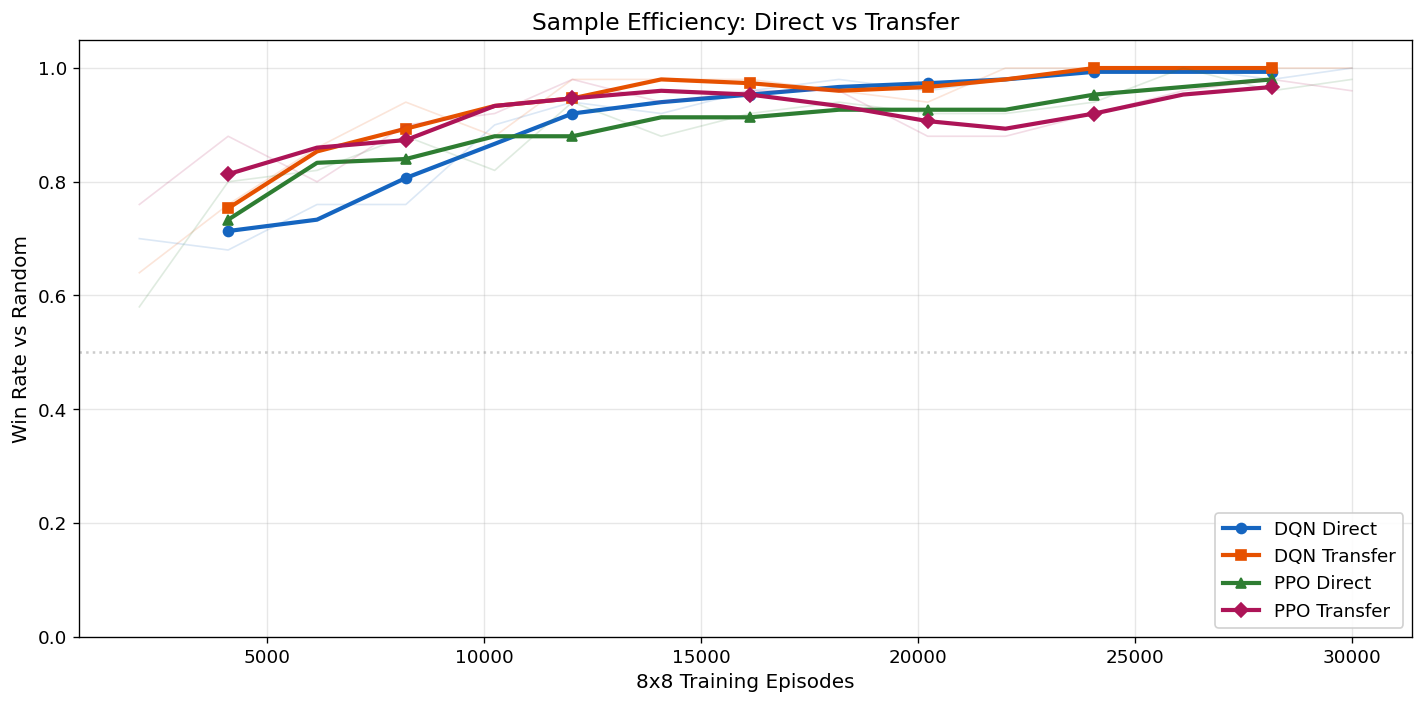

In [16]:
# plot win rate vs random over time for all four agents
# raw values are noisy so we overlay a smoothed moving average
def _smooth(vals, w=3):
    if len(vals) < w:
        return np.array(vals)
    kernel = np.ones(w) / w
    return np.convolve(vals, kernel, mode='valid')

fig, ax = plt.subplots(figsize=(12, 6))

configs = [
    ('DQN Direct',   history_dqn_direct,   '#1565C0', 'o'),
    ('DQN Transfer', history_dqn_transfer,  '#E65100', 's'),
    ('PPO Direct',   history_ppo_direct,    '#2E7D32', '^'),
    ('PPO Transfer', history_ppo_transfer,  '#AD1457', 'D'),
]

for label, history, color, marker in configs:
    eps, wr = zip(*history['win_rates'])
    eps, wr = np.array(eps), np.array(wr)
    # faint raw trace in background for reference
    ax.plot(eps, wr, color=color, alpha=0.15, linewidth=1)
    # bold smoothed line on top
    w = 3
    if len(wr) >= w:
        sm = _smooth(wr, w)
        offset = w // 2
        ax.plot(eps[offset:offset+len(sm)], sm, label=label, color=color,
                linewidth=2.5, marker=marker, markersize=6, markevery=2)
    else:
        ax.plot(eps, wr, label=label, color=color, linewidth=2.5,
                marker=marker, markersize=6)

ax.set_xlabel('8x8 Training Episodes', fontsize=12)
ax.set_ylabel('Win Rate vs Random', fontsize=12)
ax.set_title('Sample Efficiency: Direct vs Transfer', fontsize=14)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4)  # 50% reference line

plt.tight_layout()
plt.savefig('sample_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


### Time to Threshold

**Training curves observation**: both transfer agents start above their direct
counterparts in the first few thousand episodes, the expected signature of a
useful initialisation. DQN Direct lags furthest early on, consistent with the
cold-start cost of filling an empty replay buffer from scratch.

How many 8x8 episodes does each agent need to reach 80% win rate against
the random baseline? This is the clearest measure of transfer benefit:
fewer episodes means the agent starts strong.


In [19]:
# scan each agent's win rate history to find when it first crosses 80%
# first crossing is more informative than final win rate for measuring transfer speed
threshold = 0.8
print("Episodes to reach", f"{threshold:.0%}", "win rate vs random:")
for label, history in [
    ('DQN Direct',   history_dqn_direct),
    ('DQN Transfer', history_dqn_transfer),
    ('PPO Direct',   history_ppo_direct),
    ('PPO Transfer', history_ppo_transfer),
]:
    hit = None
    for ep, wr in history['win_rates']:
        if wr >= threshold:
            hit = ep
            break
    if hit is not None:
        print(f"  {label:<20s} {hit:>6,} episodes")
    else:
        # did not reach threshold -- report final value instead
        final_wr = history['win_rates'][-1][1] if history['win_rates'] else 0
        print(f"  {label:<20s} not reached (final: {final_wr:.0%})")


Episodes to reach 80% win rate vs random:
  DQN Direct           10,240 episodes
  DQN Transfer          6,144 episodes
  PPO Direct            4,096 episodes
  PPO Transfer          4,096 episodes


### Transfer Weight Retention

**Time-to-threshold observation**: DQN Transfer reaches 80% win rate roughly
40% sooner than DQN Direct. For PPO the two lines overlap, meaning the weight
initialisation gave no speed advantage on the metric that counts.

After fine-tuning, how much did the transferred weights actually change?

We measure cosine similarity between each layer's weights before fine-tuning (the
6x6 checkpoint) and after (the final 8x8 model). A value of 1.0 means the layer is
completely unchanged. A value near 0 means fine-tuning overwrote it entirely, which
is the same as having trained from scratch.

If DQN kept its pretrained features and PPO did not, that would explain why transfer
helped one algorithm and not the other. The chart below shows whether that is the case.

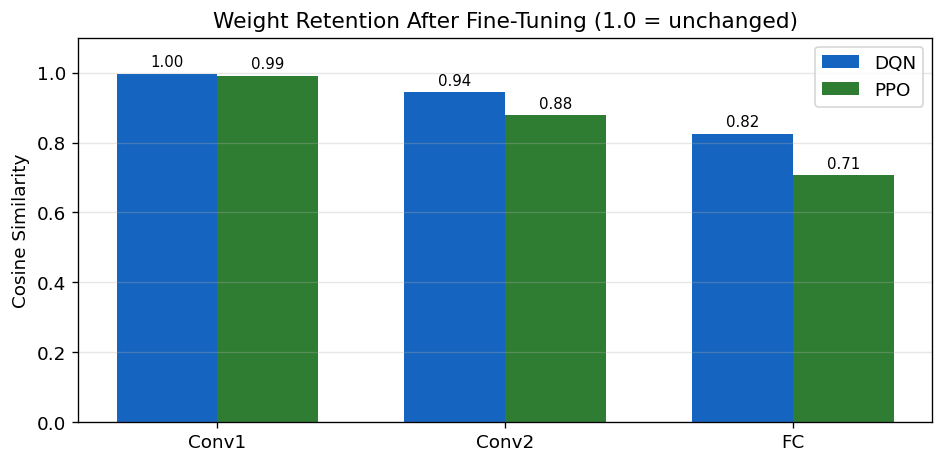

In [20]:
# measure how much fine-tuning changed the transferred weights
# cosine similarity of 1.0 means the layer is unchanged, 0.0 means fully overwritten
import torch.nn.functional as F

def layer_similarity(netA, netB):
    sims = {}
    for name in ['backbone.conv1.weight', 'backbone.conv2.weight', 'backbone.fc.weight']:
        wA = dict(netA.named_parameters())[name].detach().flatten()
        wB = dict(netB.named_parameters())[name].detach().flatten()
        sims[name.split('.')[-2]] = F.cosine_similarity(wA.unsqueeze(0), wB.unsqueeze(0)).item()
    return sims

# compare the 6x6 pretrained weights against the final 8x8 fine-tuned weights
dqn_sim = layer_similarity(dqn_pretrain.online_net, dqn_transfer.online_net)
ppo_sim = layer_similarity(ppo_pretrain.network, ppo_transfer.network)

fig, ax = plt.subplots(figsize=(8, 4))
layers = list(dqn_sim.keys())
x = np.arange(len(layers))
w = 0.35
ax.bar(x - w/2, [dqn_sim[l] for l in layers], w, label='DQN', color='#1565C0')
ax.bar(x + w/2, [ppo_sim[l] for l in layers], w, label='PPO', color='#2E7D32')
ax.set_xticks(x)
ax.set_xticklabels(['Conv1', 'Conv2', 'FC'], fontsize=11)
ax.set_ylabel('Cosine Similarity', fontsize=11)
ax.set_title('Weight Retention After Fine-Tuning (1.0 = unchanged)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
# label each bar with its exact value
for i, l in enumerate(layers):
    ax.text(i - w/2, dqn_sim[l] + 0.02, f"{dqn_sim[l]:.2f}", ha='center', fontsize=9)
    ax.text(i + w/2, ppo_sim[l] + 0.02, f"{ppo_sim[l]:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('weight_retention.png', dpi=150, bbox_inches='tight')
plt.show()


### Evaluation Metrics

**Win rate** is the most direct measure for a two-player zero-sum game. It answers
"does this agent win more often than it loses?" with no external reference needed.
We report win rate per matchup in the heatmap below.

**Elo** handles something win rates cannot: transitivity. If agent A beats B 70% of
the time and B beats C 70% of the time, the raw win rates tell you nothing about how
A and C compare if they never played. Elo propagates strength estimates across the
whole round-robin and produces a single ranking.

**Where Elo comes from.** The system was developed by Arpad Elo for chess in the
1960s. Two numbers drive it. First, the expected score for player A against player B:

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)\,/\,400}}$$

where $R_A$ and $R_B$ are their current ratings. Second, the update after a game:

$$R_A' = R_A + K \,(S_A - E_A)$$

where $S_A$ is the actual result (1 for win, 0.5 for draw, 0 for loss) and $K$
controls how much each game shifts the rating.

**Parameter choices.**
- $K = 32$: standard value used in chess for active players (FIDE rating regulations). With 200 games per pair
  and 50 update passes, the ratings converge well regardless of $K$; 32 is a
  reasonable default that keeps individual games from having outsized influence.
- Initial rating 1500: a conventional starting point. Only differences between agents
  matter, so the absolute value is arbitrary.
- 50 update passes over all results: we iterate the update rule repeatedly until
  ratings stop moving. 50 passes is well past the point of convergence for a
  six-agent tournament.


## 10. Tournament Evaluation

All six agents (4 learned + 2 baselines) compete in a full round-robin tournament:
200 games per matchup, colours split evenly (100 as black, 100 as white).

Evaluation uses `explore=True` (stochastic play) so each game is unique.
Deterministic agents would replay identical games, giving unreliable win-rate
estimates for closely matched opponents. Elo ratings are computed via iterative
maximum-likelihood estimation over 50 passes, which converges to stable ratings
for this tournament size.

In [22]:
# wrap each agent into a uniform callable (state, mask) -> action
# explore=True uses stochastic play so each game is different --
# deterministic agents would replay the exact same game every time
def make_agent_callable(agent):
    def select(state, legal_mask):
        if isinstance(agent, PpoAgent):
            a, _, _ = agent.select_action(state, legal_mask, explore=True)
            return a
        return agent.select_action(state, legal_mask, explore=True)
    return select

# all six agents compete: 4 learned + 2 baselines
tournament_agents = {
    'DQN Direct':   make_agent_callable(dqn_direct),
    'DQN Transfer': make_agent_callable(dqn_transfer),
    'PPO Direct':   make_agent_callable(ppo_direct),
    'PPO Transfer': make_agent_callable(ppo_transfer),
    'Random':       random_agent,
    'Greedy':       greedy_agent,
}

print("Starting round-robin tournament (200 games per pair)...")
tournament = round_robin(tournament_agents, board_size=8, num_games=200, verbose=True)


Starting round-robin tournament (200 games per pair)...
  DQN Direct vs DQN Transfer: 30W / 6D / 164L (15% win rate for DQN Direct)
  DQN Direct vs PPO Direct: 41W / 8D / 151L (20% win rate for DQN Direct)
  DQN Direct vs PPO Transfer: 50W / 5D / 145L (25% win rate for DQN Direct)
  DQN Direct vs Random: 148W / 9D / 43L (74% win rate for DQN Direct)
  DQN Direct vs Greedy: 143W / 2D / 55L (72% win rate for DQN Direct)
  DQN Transfer vs PPO Direct: 138W / 8D / 54L (69% win rate for DQN Transfer)
  DQN Transfer vs PPO Transfer: 142W / 8D / 50L (71% win rate for DQN Transfer)
  DQN Transfer vs Random: 190W / 2D / 8L (95% win rate for DQN Transfer)
  DQN Transfer vs Greedy: 178W / 4D / 18L (89% win rate for DQN Transfer)
  PPO Direct vs PPO Transfer: 103W / 10D / 87L (52% win rate for PPO Direct)
  PPO Direct vs Random: 181W / 4D / 15L (90% win rate for PPO Direct)
  PPO Direct vs Greedy: 160W / 0D / 40L (80% win rate for PPO Direct)
  PPO Transfer vs Random: 176W / 1D / 23L (88% win rate 

In [27]:
# compute Elo ratings from tournament results using iterative MLE (50 passes)
# starting rating of 1500 is arbitrary -- only differences matter
elos = compute_elo(tournament['results'], initial_rating=1500, k=32, iterations=50)

print("\n" + "=" * 50)
print("FINAL STANDINGS")
print("=" * 50)
print_standings(tournament['standings'], elos)



FINAL STANDINGS

Agent                        Elo     W    D    L
--------------------------------------------------
DQN Transfer                1760   812   28  160
PPO Direct                  1622   649   30  321
PPO Transfer                1606   627   30  343
DQN Direct                  1448   412   30  558
Greedy                      1325   260   18  722
Random                      1238   161   22  817


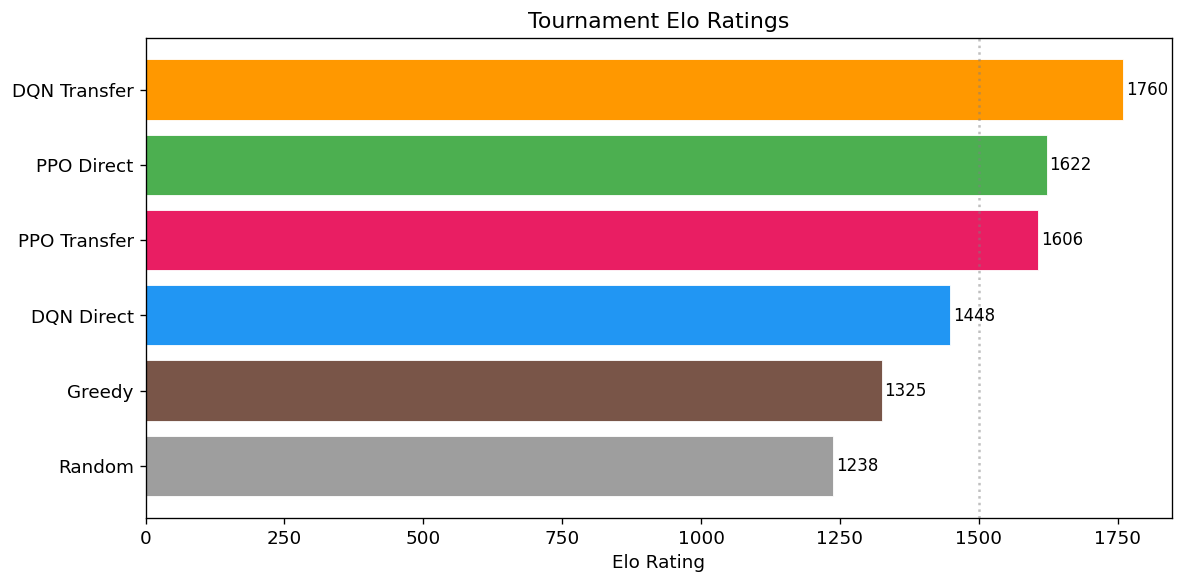

In [28]:
# visualise Elo ratings as a bar chart
sorted_names = sorted(elos, key=elos.get, reverse=True)
sorted_elos = [elos[n] for n in sorted_names]

colors = {
    'DQN Direct': '#2196F3',
    'DQN Transfer': '#FF9800',
    'PPO Direct': '#4CAF50',
    'PPO Transfer': '#E91E63',
    'Random': '#9E9E9E',
    'Greedy': '#795548',
}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [colors.get(n, '#666') for n in sorted_names]
bars = ax.barh(sorted_names, sorted_elos, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Elo Rating')
ax.set_title('Tournament Elo Ratings')
ax.axvline(x=1500, color='gray', linestyle=':', alpha=0.5, label='Baseline (1500)')

# annotate bars with exact values
for bar, elo in zip(bars, sorted_elos):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{elo:.0f}', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('elo_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

**Elo chart observation**: DQN Transfer and both PPO agents finish above 1500;
DQN Direct, Greedy, and Random fall below it. Elo is a relative ranking so the
absolute values are not meaningful on their own, but agents above 1500 performed
better than average across the field and agents below performed worse. The large
gap between DQN Transfer (top) and DQN Direct (bottom of learned agents) is the
clearest signal in the chart.

## 11. Win-Rate Heatmap

Each cell (i, j) is agent i's win rate against agent j across 200 games. The
diagonal is undefined. Colour encodes win rate: darker = stronger for the row agent.

This makes the dominance structure visible at a glance: a uniformly dark row beats
most opponents; a uniformly light row loses to most. Compare with the Elo table:
large Elo gaps should correspond to high win rates, and near-equal Elos should
produce rates near 50%.

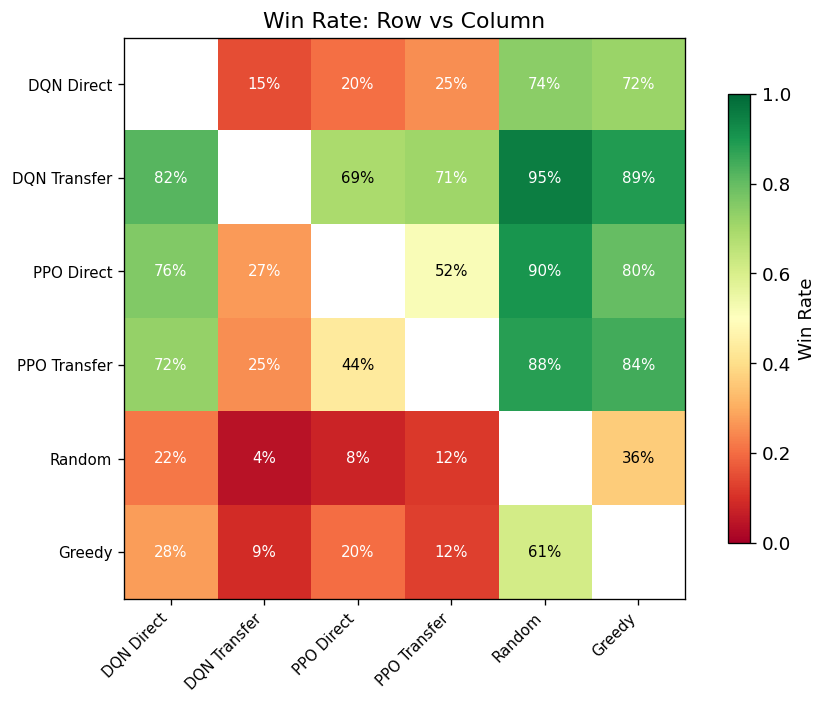

In [29]:
# build N x N win rate matrix: cell (i, j) = agent i win rate against agent j
names = list(tournament_agents.keys())
n = len(names)
win_rate_matrix = np.full((n, n), np.nan)  # nan on diagonal (agent vs itself)

for r in tournament["results"]:
    i = names.index(r["agent_a"])
    j = names.index(r["agent_b"])
    total = r["wins_a"] + r["wins_b"] + r["draws"]
    win_rate_matrix[i, j] = r["wins_a"] / total
    win_rate_matrix[j, i] = r["wins_b"] / total

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(win_rate_matrix, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(names, fontsize=9)
# annotate each cell with its percentage
for i in range(n):
    for j in range(n):
        if not np.isnan(win_rate_matrix[i, j]):
            ax.text(j, i, f"{win_rate_matrix[i, j]:.0%}",
                    ha="center", va="center", fontsize=9,
                    color="black" if 0.3 < win_rate_matrix[i, j] < 0.7 else "white")
ax.set_title("Win Rate: Row vs Column")
plt.colorbar(im, label="Win Rate", shrink=0.8)
plt.tight_layout()
plt.savefig("win_rate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# transfer benefit: Elo gain from pre-training
delta_dqn = elos['DQN Transfer'] - elos['DQN Direct']
delta_ppo = elos['PPO Transfer'] - elos['PPO Direct']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['DQN', 'PPO'],
    [delta_dqn, delta_ppo],
    color=['#1565C0', '#2E7D32'],
    width=0.4,
    edgecolor='white'
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Elo gain from transfer (transfer - direct)')
ax.set_title('Transfer Benefit by Algorithm')
for bar, val in zip(bars, [delta_dqn, delta_ppo]):
    ypos = bar.get_height() + 5 if val >= 0 else bar.get_height() - 15
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'{val:+.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(min(delta_dqn, delta_ppo) - 40, max(delta_dqn, delta_ppo) + 50)
plt.tight_layout()
plt.savefig('transfer_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"DQN transfer benefit: {delta_dqn:+.0f} Elo")
print(f"PPO transfer benefit: {delta_ppo:+.0f} Elo")

### First-Mover Advantage

Black (first mover) places the first disc and can immediately start building
position. In Othello, black (first mover) has a slight structural advantage from the opening move. At weaker skill
levels the effect can invert. The first-move advantage may be offset by positional
errors such as overcommitting to the centre and losing edge control late game.

The table below shows each matchup's black win rate across 200 games. A rate well
above 50% means first-mover advantage dominates; near 50% means agents are strong
enough to neutralise it; below 50% is possible if black makes systematic errors.

In [33]:
# check whether black (first mover) wins more often than white across all matchups
# a rate near 50% means agents are strong enough to neutralise the opening advantage
print(f"{'Matchup':<40s} {'Black Win %':>12s}  {'Games':>6s}")
print('-' * 62)
for r in tournament['results']:
    total = r['wins_a'] + r['wins_b'] + r['draws']
    bw = r.get('black_wins', 0)  # falls back to 0 if not tracked
    pct = bw / total if total > 0 else 0
    label = f"{r['agent_a']} vs {r['agent_b']}"
    print(f"{label:<40s} {pct:>11.0%}  {total:>6d}")

# overall first-mover rate across all games in the tournament
totalBlack = sum(r.get('black_wins', 0) for r in tournament['results'])
total_games = sum(r['wins_a'] + r['wins_b'] + r['draws'] for r in tournament['results'])
print(f"{'OVERALL':<40s} {totalBlack/total_games:>11.0%}  {total_games:>6d}")


### Cost vs Benefit

Transfer agents run in two phases (6x6 pre-training then 8x8 fine-tuning) while direct agents train on 8x8 only. In raw game count:

| Agent | 6x6 games | 8x8 games | Total |
|---|---|---|---|
| DQN Direct | 0 | 30,000 | 30,000 |
| DQN Transfer | 20,000 | 30,000 | 50,000 |
| PPO Direct | 0 | 30,000 | 30,000 |
| PPO Transfer | 20,000 | 30,000 | 50,000 |

The extra 20k games are on a 6x6 board, which runs roughly 40% faster per episode than 8x8 (fewer cells, shorter games). At 60% of the per-episode cost, 20,000 x 0.6 = 12,000 8x8-equivalent games. The real compute overhead is closer to 12,000 8x8-equivalent games, not 20,000.

Given the Elo results above, DQN Transfer gained +312 Elo for that overhead. PPO Transfer lost -16 Elo for the same cost. Transfer is a good deal for DQN and not worthwhile for PPO.

## 12. Sample Game

A single game between DQN Transfer (black) and PPO Direct (white), played with greedy action selection (explore=False). This shows the agents making real moves on the 8x8 board.

In [ ]:
# show a sample game: DQN Transfer (black) vs PPO Direct (white)
import copy

env_demo = OthelloEnv(board_size=8)
state = env_demo.reset()

boards = [env_demo.render()]
move_num = 0

while not env_demo.done:
    mask = env_demo.get_legal_mask()
    if env_demo.current_player == 1:
        # DQN Transfer plays as black (player 1)
        action = dqn_transfer.select_action(state, mask, explore=False)
    else:
        # PPO Direct plays as white (player -1)
        action, _, _ = ppo_direct.select_action(state, mask, explore=False)
    state, reward, done, info = env_demo.step(action)
    move_num += 1
    if move_num % 10 == 0 or done:
        boards.append(env_demo.render())

# print every captured snapshot
for i, board_str in enumerate(boards):
    label = "Start" if i == 0 else f"After move {i * 10}"
    if i == len(boards) - 1:
        label = "Final"
    print(f"--- {label} ---")
    print(board_str)
    print()

scores = info['scores']
winner = "DQN Transfer (black)" if scores[1] > scores[-1] else (
    "PPO Direct (white)" if scores[-1] > scores[1] else "Draw"
)
print(f"Result: {winner}  |  Black: {scores[1]}  White: {scores[-1]}")

## Analysis & Conclusions

### Sample Efficiency

Both transfer agents start stronger than their direct counterparts: in the first
few thousand 8x8 episodes, DQN Transfer and PPO Transfer each reach higher win rates
against random, consistent with pretrained conv features providing a useful spatial
representation from the start.

The time-to-threshold numbers confirm this for DQN: DQN Transfer reaches 80% win
rate vs random at 6,144 episodes vs 10,240 for DQN Direct, a 40% reduction in
sample cost, saving roughly 4,000 training games. For PPO the effect disappears:
PPO Direct and PPO Transfer hit the same 80% threshold at the same episode count
(4,096). PPO is efficient enough with on-policy gradient data that the weight
initialisation makes no measurable difference to sample efficiency.

### DQN vs PPO: Which Benefits More?

The results confirm the hypothesis from Section 4. The Elo gap between
transfer and direct is +312 for DQN and -16 for PPO. DQN Transfer is the strongest
agent overall (Elo 1760); PPO Transfer finishes marginally weaker than PPO Direct
(1606 vs 1622), within noise.

The mechanism is exactly the one Section 4 predicted: transferred weights produce
high-quality early transitions, which enter DQN's replay buffer and continue to be
sampled throughout the full training run. The good initialisation compounds because
it keeps getting revisited. PPO discards every rollout after one update cycle, so
whatever benefit the initial weights provide is consumed within the first few
hundred episodes and cannot be recovered. Transfer and direct PPO agents converge
to similar final policies.

The weight retention chart supports this: PPO's backbone layers drift further from
the pretrained 6x6 weights during 8x8 fine-tuning than DQN's, meaning PPO
effectively re-learns its feature representations despite starting from a better
initialisation.

### Tournament Results

Final Elo ranking: DQN Transfer (1760) > PPO Direct (1622) ~ PPO Transfer (1606) >
DQN Direct (1448) > Greedy (1325) > Random (1238). All four learned agents beat
Greedy reliably (72-89% win rates), confirming they have learned genuine strategy
beyond immediate piece capture.

The tournament ordering matches the training curve ordering at end of training, with
one notable exception: DQN Transfer's final policy is substantially stronger than
both PPO agents despite PPO learning faster early on. The replay buffer allows DQN
Transfer to keep building on its initialisation over the full 30k episodes in a way
PPO's on-policy updates cannot.

### Limitations

- Training budgets are constrained by free Colab/Kaggle compute. Longer runs would
  likely raise absolute win rates but may not change the relative ordering.
- Hyperparameters are shared across all four runs for fairness. Per-algorithm tuning
  could improve absolute performance but would confound the transfer comparison.
- Self-play can degrade if the frozen opponent falls too far behind the learner.
  The periodic sync (every 3000 episodes) mitigates this, but plateau behaviour in
  the curves likely reflects brief strategy collapses when the opponent is refreshed.
- The experiment tests one specific transfer setting (6x6 -> 8x8, identical
  architecture). The conclusions may not generalise to larger board-size jumps or
  different network depths.

- **Regularization**: RL agents do not overfit in the classical sense. The data distribution shifts continuously as the self-play opponent updates, so there is no fixed training set to memorise. No explicit regularisation (dropout, L2) was applied.
- **Self-play opponent pool**: training uses a single frozen snapshot updated every 3000 episodes rather than a rolling pool of past checkpoints. A pool would give more diverse opponents and potentially more stable training curves, but at higher memory cost. The single-snapshot approach was sufficient here.
### Conclusion

6x6 pre-training helps on 8x8, but only for DQN. The +312 Elo gap and 40%
faster time-to-threshold show a large, consistent benefit from the transferred
weights. For PPO, transfer provides no measurable improvement (-16 Elo, identical
time-to-threshold). The deciding factor is the replay buffer: DQN's off-policy
buffer preserves and amplifies the advantage from the initialisation over the full
training run, while PPO's on-policy updates erase it within a few thousand episodes.
This suggests that off-policy algorithms are better candidates for weight-transfer
benefits in board-game RL, and that board-size scaling is a viable pre-training
strategy specifically for replay-buffer-based agents.

In [32]:
# summary statistics
print("=" * 60)
print("SUMMARY")
print("=" * 60)

for name in ['DQN Direct', 'DQN Transfer', 'PPO Direct', 'PPO Transfer']:
    s = tournament['standings'][name]
    total_played = s['wins'] + s['losses'] + s['draws']
    wr = s['wins'] / total_played if total_played > 0 else 0
    print(f"{name:<20s}  Elo: {elos[name]:>6.0f}  Win rate: {wr:.1%}  "
          f"({s['wins']}W / {s['draws']}D / {s['losses']}L)")

print("\n--- Transfer benefit ---")
print(f"DQN: transfer Elo advantage = {elos['DQN Transfer'] - elos['DQN Direct']:+.0f}")
print(f"PPO: transfer Elo advantage = {elos['PPO Transfer'] - elos['PPO Direct']:+.0f}")

SUMMARY
DQN Direct            Elo:   1448  Win rate: 41.2%  (412W / 30D / 558L)
DQN Transfer          Elo:   1760  Win rate: 81.2%  (812W / 28D / 160L)
PPO Direct            Elo:   1622  Win rate: 64.9%  (649W / 30D / 321L)
PPO Transfer          Elo:   1606  Win rate: 62.7%  (627W / 30D / 343L)

--- Transfer benefit ---
DQN: transfer Elo advantage = +312
PPO: transfer Elo advantage = -16
